# Where Should We Focus to Drive Sustainable Customer Growth?

### A Consumer Insights Analysis of Household Purchase Behavior and Growth Opportunities

## Business Question

Where should the business focus its growth efforts to drive sustainable customer value?

This analysis examines household purchase behavior to identify where customer engagement is strengthening, where value is at risk, and which areas may represent the most relevant opportunities for targeted action.

## Executive Summary

Total sales increased by 28.4% between the first and second periods, indicating overall business growth.

However, this growth was not evenly distributed across households. The analysis identified 871 households with declining purchase frequency, including 394 households where both purchase frequency and basket spend decreased.

This critical segment generated 284K in negative sales value change and showed broad-based declines across core categories. Grocery represented the largest category-level sales loss at 151K.

The findings suggest that sustainable growth may require a more targeted approach to customer recovery, with different interventions for declining frequency, declining basket value, and customers experiencing both.

## Key Findings

### 1. Overall sales growth
Sales increased by 28.4% between the first and second periods, from 3.53M to 4.53M.

### 2. Customer engagement is uneven
871 households reduced purchase frequency, including 394 households where both frequency and basket spend declined.

### 3. Customer value is concentrated in a critical risk segment
The 394 at-risk households generated 284K in negative sales value change.

### 4. Grocery is the largest category-level loss
Within the critical segment, Grocery accounted for 151K in sales loss, substantially more than any other department.

## Data & Methodology

### Dataset

The analysis uses the dunnhumby Complete Journey dataset, which contains approximately two years of household-level transaction data for 2,500 frequent-shopper households.

The transaction data includes purchase occasions, products, quantities, sales value, store information, discounts and campaign-related variables.

### Analytical Approach

The analysis follows a decision-oriented consumer insights approach:

**Data → Customer Behavior → Insight → Opportunity → Strategic Options**

Households were compared across two periods using three behavioral measures:

- **Purchase Frequency:** Number of unique baskets per household.
- **Basket Spend:** Sales value per purchase occasion.
- **Sales Change:** Difference in total sales value between the two periods.

Households were then grouped according to whether purchase frequency and basket spend increased or decreased.

The analysis focuses on identifying customer-level growth patterns, areas of customer-value risk and category-level opportunities for targeted action.

## 1. Data Loading & Quality Check

In [7058]:
import pandas as pd

file_path = "../data/raw/dunnhumby_The-Complete-Journey CSV/transaction_data.csv"

transactions = pd.read_csv(file_path)

transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


In [7059]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 2595732 entries, 0 to 2595731
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   TRANS_TIME         int64  
 9   WEEK_NO            int64  
 10  COUPON_DISC        float64
 11  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(8)
memory usage: 237.6 MB


In [7060]:
transactions.isnull().sum()

household_key        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QUANTITY             0
SALES_VALUE          0
STORE_ID             0
RETAIL_DISC          0
TRANS_TIME           0
WEEK_NO              0
COUPON_DISC          0
COUPON_MATCH_DISC    0
dtype: int64

In [7061]:
transactions.duplicated().sum()

np.int64(0)

In [7062]:
transactions.describe()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
count,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06
mean,1.271953e+03,3.402620e+10,3.887562e+02,2.891435e+06,1.004286e+02,3.104120e+00,3.142673e+03,-5.387054e-01,1.561586e+03,5.622150e+01,-1.641600e-02,-2.918564e-03
std,7.260660e+02,4.711649e+09,1.897210e+02,3.837404e+06,1.153436e+03,4.182274e+00,8.937113e+03,1.249191e+00,3.998378e+02,2.710223e+01,2.168410e-01,3.969004e-02
min,1.000000e+00,2.698485e+10,1.000000e+00,2.567100e+04,0.000000e+00,0.000000e+00,1.000000e+00,-1.800000e+02,0.000000e+00,1.000000e+00,-5.593000e+01,-7.700000e+00
25%,6.560000e+02,3.040805e+10,2.290000e+02,9.174590e+05,1.000000e+00,1.290000e+00,3.300000e+02,-6.900000e-01,1.308000e+03,3.300000e+01,0.000000e+00,0.000000e+00
50%,1.272000e+03,3.276081e+10,3.900000e+02,1.028816e+06,1.000000e+00,2.000000e+00,3.720000e+02,-1.000000e-02,1.613000e+03,5.600000e+01,0.000000e+00,0.000000e+00
75%,1.913000e+03,4.012685e+10,5.530000e+02,1.133018e+06,1.000000e+00,3.490000e+00,4.220000e+02,0.000000e+00,1.843000e+03,8.000000e+01,0.000000e+00,0.000000e+00
max,2.500000e+03,4.230536e+10,7.110000e+02,1.831630e+07,8.963800e+04,8.400000e+02,3.428000e+04,3.990000e+00,2.359000e+03,1.020000e+02,0.000000e+00,0.000000e+00


In [7063]:
transactions.columns

Index(['household_key', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY',
       'SALES_VALUE', 'STORE_ID', 'RETAIL_DISC', 'TRANS_TIME', 'WEEK_NO',
       'COUPON_DISC', 'COUPON_MATCH_DISC'],
      dtype='str')

## 2. Product & Category Data

In [7064]:
products = pd.read_csv("../data/raw/dunnhumby_The-Complete-Journey CSV/product.csv")

products.head()

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


In [7065]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   PRODUCT_ID            92353 non-null  int64
 1   MANUFACTURER          92353 non-null  int64
 2   DEPARTMENT            92353 non-null  str  
 3   BRAND                 92353 non-null  str  
 4   COMMODITY_DESC        92353 non-null  str  
 5   SUB_COMMODITY_DESC    92353 non-null  str  
 6   CURR_SIZE_OF_PRODUCT  92353 non-null  str  
dtypes: int64(2), str(5)
memory usage: 4.9 MB


In [7066]:
transactions["PRODUCT_ID"].nunique()

92339

In [7067]:
product_ids_in_transactions = set(transactions["PRODUCT_ID"].unique())
product_ids_in_products = set(products["PRODUCT_ID"].unique())

missing_products = product_ids_in_transactions - product_ids_in_products

len(missing_products)

0

## 3. Transaction & Category Analysis

In [7068]:
transaction_products = transactions.merge(
    products,
    on="PRODUCT_ID",
    how="left"
)

transaction_products.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0,69,PRODUCE,Private,POTATOES,POTATOES RUSSET (BULK&BAG),5 LB
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0,2,PRODUCE,National,ONIONS,ONIONS SWEET (BULK&BAG),40 LB
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0,69,PRODUCE,Private,VEGETABLES - ALL OTHERS,CELERY,
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0,69,PRODUCE,Private,ORGANICS FRUIT & VEGETABLES,ORGANIC CARROTS,1 LB


In [7069]:
transaction_products.shape

(2595732, 18)

In [7070]:
transactions["DAY"].min(), transactions["DAY"].max()

(np.int64(1), np.int64(711))

In [7071]:
transactions["household_key"].nunique(), transactions["BASKET_ID"].nunique()

(2500, 276484)

In [7072]:
transactions["SALES_VALUE"].sum()

np.float64(8057463.08)

In [7073]:
transaction_products["DEPARTMENT"].value_counts()

DEPARTMENT
GROCERY            1646076
DRUG GM             277232
PRODUCE             257290
MEAT-PCKGD          111957
MEAT                 88416
DELI                 62787
PASTRY               38179
NUTRITION            32164
KIOSK-GAS            22059
SEAFOOD-PCKGD        11216
SALAD BAR             9516
                      7839
COSMETICS             7692
MISC SALES TRAN       6050
FLORAL                4524
SEAFOOD               4093
MISC. TRANS.          2351
SPIRITS               2119
TRAVEL & LEISUR        862
COUP/STR & MFG         817
CHEF SHOPPE            766
GARDEN CENTER          720
RESTAURANT             465
FROZEN GROCERY         251
AUTOMOTIVE              65
DAIRY DELI              53
GM MERCH EXP            49
CNTRL/STORE SUP         21
POSTAL CENTER           20
PHOTO                   17
RX                      14
DELI/SNACK BAR          11
PHARMACY SUPPLY          6
MEAT-WHSE                6
VIDEO RENTAL             5
TOYS                     5
PROD-WHS SALES   

In [7074]:
transaction_products.groupby("DEPARTMENT")["SALES_VALUE"].sum().sort_values(ascending=False)

DEPARTMENT
GROCERY            4093814.14
DRUG GM            1055358.03
PRODUCE             557452.11
MEAT                548786.81
KIOSK-GAS           544222.28
MEAT-PCKGD          412436.77
DELI                260866.51
PASTRY              121739.86
MISC SALES TRAN     119960.04
NUTRITION            97669.04
SEAFOOD-PCKGD        63093.62
FLORAL               39653.34
COSMETICS            32360.37
SALAD BAR            30953.30
SEAFOOD              29496.92
SPIRITS              21670.88
MISC. TRANS.         10678.69
GARDEN CENTER         7667.82
TRAVEL & LEISUR       2550.38
CHEF SHOPPE           2290.80
RESTAURANT            1986.76
COUP/STR & MFG        1027.72
FROZEN GROCERY         653.26
AUTOMOTIVE             452.66
RX                     159.56
GM MERCH EXP           101.10
DAIRY DELI              73.23
CNTRL/STORE SUP         49.05
PHOTO                   41.40
DELI/SNACK BAR          36.08
VIDEO                   34.77
POSTAL CENTER           24.01
VIDEO RENTAL            21.46

In [7075]:
transaction_products.groupby("DEPARTMENT")["SALES_VALUE"].agg(["sum", "mean", "count"]).sort_values("sum", ascending=False)

,sum,mean,count
DEPARTMENT,,,
GROCERY,4093814.14,2.487014,1646076
DRUG GM,1055358.03,3.806768,277232
PRODUCE,557452.11,2.166630,257290
MEAT,548786.81,6.206872,88416
KIOSK-GAS,544222.28,24.671213,22059
MEAT-PCKGD,412436.77,3.683886,111957
DELI,260866.51,4.154785,62787
PASTRY,121739.86,3.188660,38179
MISC SALES TRAN,119960.04,19.828106,6050


In [7076]:
transaction_products[transaction_products["DEPARTMENT"].isna()][
    ["PRODUCT_ID", "SALES_VALUE"]
].head(10)

,PRODUCT_ID,SALES_VALUE


In [7077]:
transaction_products[
    transaction_products["DEPARTMENT"] == "0.00"
][["PRODUCT_ID", "SALES_VALUE"]].head(10)

,PRODUCT_ID,SALES_VALUE


In [7078]:
transaction_products["DEPARTMENT"].value_counts(dropna=False).tail(5)

DEPARTMENT
PORK               2
CHARITABLE CONT    2
GRO BAKERY         2
HOUSEWARES         1
ELECT &PLUMBING    1
Name: count, dtype: int64

In [7079]:
transaction_products["DEPARTMENT"].unique()[-10:]

<StringArray>
['CHARITABLE CONT',              'RX',            'TOYS',           'PHOTO',
  'DELI/SNACK BAR',      'GRO BAKERY', 'PHARMACY SUPPLY', 'ELECT &PLUMBING',
       'MEAT-WHSE',           'VIDEO']
Length: 10, dtype: str

## 4. Customer Behavior Segmentation

In [ ]:


# First and second period
transactions_clean = transactions.copy()

transactions_clean["period"] = transactions_clean["DAY"].apply(
    lambda d: "first_period" if d <= 355 else "second_period"
)

# 1. Sales by customer and period
customer_sales_clean = (
    transactions_clean
    .groupby(["household_key", "period"])["SALES_VALUE"]
    .sum()
    .unstack(fill_value=0)
)

# 2. Basket frequency by customer and period
customer_frequency_clean = (
    transactions_clean
    .groupby(["household_key", "period"])["BASKET_ID"]
    .nunique()
    .unstack(fill_value=0)
)

# 3. Basket spend by customer and period
customer_basket_spend_clean = (
    customer_sales_clean / customer_frequency_clean
)

# 4. Changes: second period - first period
customer_clean = customer_sales_clean.copy()

customer_clean["sales_change"] = (
    customer_sales_clean["second_period"]
    - customer_sales_clean["first_period"]
)

customer_clean["frequency_change"] = (
    customer_frequency_clean["second_period"]
    - customer_frequency_clean["first_period"]
)

customer_clean["basket_spend_change"] = (
    customer_basket_spend_clean["second_period"]
    - customer_basket_spend_clean["first_period"]
)

# 5. Create behavior segments
customer_clean["behavior_type"] = customer_clean.apply(
    lambda row:
        "Frequency + Basket Spend Increased"
        if row["frequency_change"] > 0
        and row["basket_spend_change"] > 0

        else "Frequency Increased, Basket Spend Decreased"
        if row["frequency_change"] > 0
        and row["basket_spend_change"] < 0

        else "Frequency Decreased, Basket Spend Increased"
        if row["frequency_change"] < 0
        and row["basket_spend_change"] > 0

        else "Frequency + Basket Spend Decreased"
        if row["frequency_change"] < 0
        and row["basket_spend_change"] < 0

        else "Other",
    axis=1
)

customer_clean["behavior_type"].value_counts()

behavior_type
Frequency + Basket Spend Increased             813
Frequency Increased, Basket Spend Decreased    725
Frequency Decreased, Basket Spend Increased    477
Frequency + Basket Spend Decreased             394
Other                                           91
Name: count, dtype: int64

In [7128]:
customer_clean.groupby("behavior_type")["sales_change"].agg(
    ["count", "sum", "mean", "median"]
).sort_values("sum", ascending=True)

,count,sum,mean,median
behavior_type,,,,
Frequency + Basket Spend Decreased,394,-284393.83,-721.811751,-438.88
"Frequency Decreased, Basket Spend Increased",477,-75288.12,-157.836730,-66.21
Other,91,1209.08,13.286593,-19.17
"Frequency Increased, Basket Spend Decreased",725,449045.19,619.372676,320.64
Frequency + Basket Spend Increased,813,910279.44,1119.654908,827.18


In [7129]:
customer_clean[
    customer_clean["frequency_change"] < 0
].groupby("behavior_type")[
    ["sales_change", "frequency_change", "basket_spend_change"]
].agg(
    ["count", "sum", "mean", "median"]
)

period                                      sales_change             \
                                                   count        sum   
behavior_type                                                         
Frequency + Basket Spend Decreased                   394 -284393.83   
Frequency Decreased, Basket Spend Increased          477  -75288.12   
Other                                                 21   -5271.39   

period                                                           \
                                                   mean  median   
behavior_type                                                     
Frequency + Basket Spend Decreased          -721.811751 -438.88   
Frequency Decreased, Basket Spend Increased -157.836730  -66.21   
Other                                       -251.018571 -160.06   

period                                      frequency_change         \
                                                       count    sum   
behavior_type                                                         
Frequency + Basket Spend Decreased                       394  -7238   
Frequency Decreased, Basket Spend Increased              477 -11322   
Other                                                     21   -147   

period                                                         \
                                                  mean median   
behavior_type                                                   
Frequency + Basket Spend Decreased          -18.370558  -10.0   
Frequency Decreased, Basket Spend Increased -23.735849  -12.0   
Other                                        -7.000000   -6.0   

period                                      basket_spend_change               \
                                                          count          sum   
behavior_type                                                                  
Frequency + Basket Spend Decreased                          394 -3622.074991   
Frequency Decreased, Basket Spend Increased                 477  5351.979781   
Other                                                         0     0.000000   

period                                                            
                                                  mean    median  
behavior_type                                                     
Frequency + Basket Spend Decreased           -9.193084 -5.767037  
Frequency Decreased, Basket Spend Increased  11.220083  6.658733  
Other                                              NaN       NaN

## 5. Category-Level Opportunity Analysis

In [7130]:
# The 394 households with both lower frequency and lower basket spend

critical_households = customer_clean[
    customer_clean["behavior_type"] == "Frequency + Basket Spend Decreased"
].index

critical_transactions = transaction_products[
    transaction_products["household_key"].isin(critical_households)
]

critical_category_sales = (
    critical_transactions
    .assign(
        period=lambda x: x["DAY"].apply(
            lambda d: "first_period" if d <= 355 else "second_period"
        )
    )
    .groupby(["DEPARTMENT", "period"])["SALES_VALUE"]
    .sum()
    .unstack(fill_value=0)
)

critical_category_sales["sales_change"] = (
    critical_category_sales["second_period"]
    - critical_category_sales["first_period"]
)

critical_category_sales["sales_loss"] = (
    critical_category_sales["first_period"]
    - critical_category_sales["second_period"]
)

critical_category_sales[
    critical_category_sales["first_period"] >= 10000
].sort_values(
    "sales_loss",
    ascending=False
).head(10)

period,first_period,second_period,sales_change,sales_loss
DEPARTMENT,,,,
GROCERY,312685.24,161941.21,-150744.03,150744.03
DRUG GM,85695.01,47675.03,-38019.98,38019.98
MEAT,41450.76,19392.91,-22057.85,22057.85
MEAT-PCKGD,34757.42,16981.51,-17775.91,17775.91
PRODUCE,37886.55,21076.99,-16809.56,16809.56
KIOSK-GAS,32674.65,17059.67,-15614.98,15614.98
DELI,18842.48,9945.70,-8896.78,8896.78


In [7131]:
demographics = pd.read_csv(
    "../data/raw/dunnhumby_The-Complete-Journey CSV/hh_demographic.csv"
)

demographics.head()

,classification_1,classification_2,classification_3,HOMEOWNER_DESC,classification_5,classification_4,KID_CATEGORY_DESC,household_key
0,Age Group6,X,Level4,Homeowner,Group5,2,None/Unknown,1
1,Age Group4,X,Level5,Homeowner,Group5,2,None/Unknown,7
2,Age Group2,Y,Level3,Unknown,Group4,3,1,8
3,Age Group2,Y,Level6,Homeowner,Group4,4,2,13
4,Age Group4,Z,Level5,Homeowner,Group3,1,None/Unknown,16


## 6. Demographic Context

In [7132]:
critical_demographics = demographics[
    demographics["household_key"].isin(critical_households)
]

critical_demographics.shape

(73, 8)

In [7133]:
critical_demographics.head(20)

,classification_1,classification_2,classification_3,HOMEOWNER_DESC,classification_5,classification_4,KID_CATEGORY_DESC,household_key
4,Age Group4,Z,Level5,Homeowner,Group3,1,None/Unknown,16
13,Age Group3,X,Level8,Homeowner,Group5,2,None/Unknown,39
16,Age Group3,Z,Level2,Homeowner,Group4,5+,3+,43
26,Age Group3,X,Level3,Homeowner,Group3,2,None/Unknown,71
79,Age Group3,X,Level4,Unknown,Group5,2,None/Unknown,222
82,Age Group3,X,Level12,Homeowner,Group4,5+,3+,235
93,Age Group4,Y,Level6,Homeowner,Group5,2,None/Unknown,264
100,Age Group2,X,Level5,Homeowner,Group4,4,2,294
101,Age Group5,X,Level1,Unknown,Group3,2,None/Unknown,300
106,Age Group2,X,Level6,Homeowner,Group2,2,None/Unknown,309


In [7134]:
critical_demographics["classification_1"].value_counts()

classification_1
Age Group4    22
Age Group3    22
Age Group2    12
Age Group5     7
Age Group6     6
Age Group1     4
Name: count, dtype: int64

In [7135]:
critical_demographics["classification_2"].value_counts()

classification_2
Y    35
X    29
Z     9
Name: count, dtype: int64

In [7136]:
critical_demographics["classification_3"].value_counts()

classification_3
Level5     14
Level1     14
Level4     11
Level3      9
Level6      9
Level8      5
Level2      4
Level12     2
Level7      2
Level10     2
Level9      1
Name: count, dtype: int64

In [7137]:
critical_demographics["HOMEOWNER_DESC"].value_counts()

HOMEOWNER_DESC
Homeowner          45
Unknown            22
Renter              5
Probable Renter     1
Name: count, dtype: int64

In [7138]:
critical_demographics["classification_5"].value_counts()

classification_5
Group4    19
Group3    17
Group5    17
Group2     9
Group6     6
Group1     5
Name: count, dtype: int64

In [7139]:
critical_demographics["classification_4"].value_counts()

classification_4
2     26
1     22
3     11
5+     8
4      6
Name: count, dtype: int64

In [7140]:
critical_demographics["KID_CATEGORY_DESC"].value_counts()

KID_CATEGORY_DESC
None/Unknown    46
1               11
3+               8
2                8
Name: count, dtype: int64

## 7. Campaign Analysis

In [7141]:
campaign_table = pd.read_csv(
    "../data/raw/dunnhumby_The-Complete-Journey CSV/campaign_table.csv"
)

campaign_table.head()

,DESCRIPTION,household_key,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26
3,TypeA,208,26
4,TypeA,192,26


In [7142]:
campaign_table["DESCRIPTION"].value_counts()

DESCRIPTION
TypeA    3979
TypeB    2655
TypeC     574
Name: count, dtype: int64

In [7143]:
critical_campaigns = campaign_table[
    campaign_table["household_key"].isin(critical_households)
]

critical_campaigns["household_key"].nunique()

236

In [7144]:
critical_campaigns.groupby("household_key")["CAMPAIGN"].nunique().describe()

count    236.000000
mean       3.851695
std        2.775125
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       15.000000
Name: CAMPAIGN, dtype: float64

In [7145]:
critical_campaigns["DESCRIPTION"].value_counts()

DESCRIPTION
TypeA    592
TypeB    257
TypeC     60
Name: count, dtype: int64

In [7146]:
customer_clean.loc[
    critical_households,
    ["sales_change", "frequency_change", "basket_spend_change"]
].assign(
    campaign_received=lambda x: x.index.isin(
        critical_campaigns["household_key"].unique()
    )
).groupby("campaign_received")[
    ["sales_change", "frequency_change", "basket_spend_change"]
].agg(["count", "mean", "median"])

period            sales_change                      frequency_change  \
                         count        mean   median            count   
campaign_received                                                      
False                      158 -329.495380 -223.905              158   
True                       236 -984.464237 -682.090              236   

period                              basket_spend_change                       
                        mean median               count       mean    median  
campaign_received                                                             
False              -8.170886   -6.0                 158 -11.574348 -7.111192  
True              -25.199153  -15.0                 236  -7.598847 -5.438944

In [7147]:
campaign_timing = campaign_table[
    campaign_table["household_key"].isin(critical_households)
].copy()

campaign_timing.groupby("CAMPAIGN")["household_key"].nunique().sort_values(ascending=False)

CAMPAIGN
8     163
13    154
18    117
30     83
26     75
22     30
7      29
14     29
29     25
5      24
11     21
20     16
10     15
9      14
12     12
2      12
16     12
17     11
25     11
19     10
23      8
6       7
28      6
24      6
4       5
21      4
27      4
3       2
1       2
15      2
Name: household_key, dtype: int64

In [7148]:
campaign_coverage = (
    campaign_table[
        campaign_table["household_key"].isin(critical_households)
    ]
    .groupby("CAMPAIGN")["household_key"]
    .nunique()
    .reset_index(name="critical_households")
    .sort_values("critical_households", ascending=False)
)

campaign_coverage.head(10)

,CAMPAIGN,critical_households
7,8,163
12,13,154
17,18,117
29,30,83
25,26,75
21,22,30
6,7,29
13,14,29
28,29,25
4,5,24


In [7149]:
campaign_performance = (
    customer_clean.loc[
        critical_households,
        ["sales_change", "frequency_change", "basket_spend_change"]
    ]
    .reset_index()
    .rename(columns={"index": "household_key"})
    .merge(
        campaign_table[["household_key", "CAMPAIGN"]].drop_duplicates(),
        on="household_key",
        how="inner"
    )
    .groupby("CAMPAIGN")
    .agg(
        critical_households=("household_key", "nunique"),
        avg_sales_change=("sales_change", "mean"),
        median_sales_change=("sales_change", "median"),
        avg_frequency_change=("frequency_change", "mean"),
        avg_basket_spend_change=("basket_spend_change", "mean")
    )
    .sort_values("critical_households", ascending=False)
)

campaign_performance.head(10)

,critical_households,avg_sales_change,median_sales_change,avg_frequency_change,avg_basket_spend_change
CAMPAIGN,,,,,
8,163,-1049.360245,-728.730,-27.141104,-7.335002
13,154,-1192.061039,-935.710,-30.337662,-6.943532
18,117,-1262.109915,-1050.380,-33.555556,-6.598009
30,83,-1274.276265,-984.360,-33.289157,-7.628207
26,75,-1289.616533,-877.010,-32.426667,-9.334834
22,30,-1449.494000,-1327.605,-36.600000,-6.666386
7,29,-1436.696552,-1056.940,-36.448276,-8.408386
14,29,-1513.958276,-1209.580,-37.068966,-7.646239
29,25,-912.260400,-602.710,-18.240000,-6.518372


In [7150]:
campaign_desc = pd.read_csv(
    "../data/raw/dunnhumby_The-Complete-Journey CSV/campaign_desc.csv"
)

campaign_desc

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,659,719
1,TypeC,15,547,708
2,TypeB,25,659,691
3,TypeC,20,615,685
4,TypeB,23,646,684
5,TypeB,21,624,656
6,TypeB,22,624,656
7,TypeA,18,587,642
8,TypeB,19,603,635
9,TypeB,17,575,607


In [7151]:
campaign_exposure = (
    campaign_table[
        campaign_table["household_key"].isin(critical_households)
    ]
    .merge(
        campaign_desc[["CAMPAIGN", "START_DAY", "END_DAY", "DESCRIPTION"]],
        on="CAMPAIGN",
        how="left"
    )
)

campaign_exposure.head(10)

,DESCRIPTION_x,household_key,CAMPAIGN,START_DAY,END_DAY,DESCRIPTION_y
0,TypeA,187,26,224,264,TypeA
1,TypeA,183,26,224,264,TypeA
2,TypeA,142,26,224,264,TypeA
3,TypeA,2459,26,224,264,TypeA
4,TypeA,2443,26,224,264,TypeA
5,TypeA,2384,26,224,264,TypeA
6,TypeA,2371,26,224,264,TypeA
7,TypeA,2318,26,224,264,TypeA
8,TypeA,2213,26,224,264,TypeA
9,TypeA,2208,26,224,264,TypeA


In [7152]:
campaign_8_households = campaign_table.loc[
    campaign_table["CAMPAIGN"] == 8,
    "household_key"
].unique()

campaign_8_households = [
    h for h in campaign_8_households
    if h in critical_households
]

campaign_8_transactions = transactions_clean[
    transactions_clean["household_key"].isin(campaign_8_households)
].copy()

campaign_8_transactions["campaign_period"] = campaign_8_transactions["DAY"].apply(
    lambda d:
        "before_campaign" if d < 587
        else "during_campaign" if d <= 642
        else "after_campaign"
)

campaign_8_summary = (
    campaign_8_transactions
    .groupby("campaign_period")
    .agg(
        households=("household_key", "nunique"),
        baskets=("BASKET_ID", "nunique"),
        sales=("SALES_VALUE", "sum")
    )
)

campaign_8_summary

,households,baskets,sales
campaign_period,,,
after_campaign,146,1266,34885.49
before_campaign,163,20143,539827.24
during_campaign,145,1115,30352.75


In [7153]:
campaign_8_daily = campaign_8_summary.copy()

period_days = {
    "before_campaign": 586,
    "during_campaign": 56,
    "after_campaign": 69
}

campaign_8_daily["days"] = campaign_8_daily.index.map(period_days)

campaign_8_daily["sales_per_household_per_day"] = (
    campaign_8_daily["sales"]
    / campaign_8_daily["households"]
    / campaign_8_daily["days"]
)

campaign_8_daily["baskets_per_household_per_day"] = (
    campaign_8_daily["baskets"]
    / campaign_8_daily["households"]
    / campaign_8_daily["days"]
)

campaign_8_daily

,households,baskets,sales,days,sales_per_household_per_day,baskets_per_household_per_day
campaign_period,,,,,,
after_campaign,146,1266,34885.49,69,3.462923,0.125670
before_campaign,163,20143,539827.24,586,5.651576,0.210882
during_campaign,145,1115,30352.75,56,3.738023,0.137315


In [ ]:
campaign_8_daily_trend = (
    transactions_clean[
        transactions_clean["household_key"].isin(campaign_8_households)
    ]
    .groupby("DAY")
    .agg(
        households=("household_key", "nunique"),
        baskets=("BASKET_ID", "nunique"),
        sales=("SALES_VALUE", "sum")
    )
)

campaign_8_daily_trend["sales_per_household"] = (
    campaign_8_daily_trend["sales"]
    / campaign_8_daily_trend["households"]
)

campaign_8_daily_trend["baskets_per_household"] = (
    campaign_8_daily_trend["baskets"]
    / campaign_8_daily_trend["households"]
)


,households,baskets,sales,sales_per_household,baskets_per_household
DAY,,,,,
1,1,1,139.22,139.220000,1.000000
3,3,3,39.58,13.193333,1.000000
4,1,1,13.65,13.650000,1.000000
5,2,2,41.11,20.555000,1.000000
6,4,6,130.55,32.637500,1.500000
7,3,3,219.48,73.160000,1.000000
8,4,4,82.72,20.680000,1.000000
9,3,3,62.23,20.743333,1.000000
10,2,2,38.56,19.280000,1.000000


In [7155]:
campaign_8_weekly_trend = (
    transactions_clean[
        transactions_clean["household_key"].isin(campaign_8_households)
    ]
    .groupby("WEEK_NO")
    .agg(
        households=("household_key", "nunique"),
        baskets=("BASKET_ID", "nunique"),
        sales=("SALES_VALUE", "sum")
    )
)

campaign_8_weekly_trend["sales_per_household"] = (
    campaign_8_weekly_trend["sales"]
    / campaign_8_weekly_trend["households"]
)

campaign_8_weekly_trend["baskets_per_household"] = (
    campaign_8_weekly_trend["baskets"]
    / campaign_8_weekly_trend["households"]
)

campaign_8_weekly_trend

,households,baskets,sales,sales_per_household,baskets_per_household
WEEK_NO,,,,,
1,4,7,233.56,58.390000,1.750000
2,16,33,1583.59,98.974375,2.062500
3,18,40,866.13,48.118333,2.222222
4,33,74,2983.55,90.410606,2.242424
5,39,84,2118.02,54.308205,2.153846
...,...,...,...,...,...
98,76,132,3683.38,48.465526,1.736842
99,81,149,4021.32,49.645926,1.839506
100,71,128,3563.18,50.185634,1.802817


In [7156]:
campaign_8_weekly_trend.loc[
    75:95,
    ["households", "baskets", "sales", "sales_per_household", "baskets_per_household"]
]

,households,baskets,sales,sales_per_household,baskets_per_household
WEEK_NO,,,,,
75,88,184,3885.02,44.147955,2.090909
76,79,172,3852.76,48.769114,2.177215
77,84,185,4163.38,49.564048,2.202381
78,77,155,2984.83,38.764026,2.012987
79,75,167,3581.36,47.751467,2.226667
80,83,174,3153.26,37.991084,2.096386
81,78,148,4038.36,51.773846,1.897436
82,85,138,3290.66,38.713647,1.623529
83,66,125,3040.81,46.072879,1.893939


In [7157]:
campaign_8_weekly_comparison = pd.DataFrame({
    "period": ["before", "during", "after"],
    "avg_sales_per_household": [
        campaign_8_weekly_trend.loc[1:83, "sales_per_household"].mean(),
        campaign_8_weekly_trend.loc[84:92, "sales_per_household"].mean(),
        campaign_8_weekly_trend.loc[93:102, "sales_per_household"].mean()
    ],
    "avg_baskets_per_household": [
        campaign_8_weekly_trend.loc[1:83, "baskets_per_household"].mean(),
        campaign_8_weekly_trend.loc[84:92, "baskets_per_household"].mean(),
        campaign_8_weekly_trend.loc[93:102, "baskets_per_household"].mean()
    ]
})

campaign_8_weekly_comparison

,period,avg_sales_per_household,avg_baskets_per_household
0,before,65.017892,2.420856
1,during,49.840768,1.835163
2,after,48.652044,1.764279


In [7158]:
period_sales = (
    transactions_clean
    .groupby("period")["SALES_VALUE"]
    .sum()
    .reindex(["first_period", "second_period"])
)

period_sales

period
first_period     3528305.66
second_period    4529157.42
Name: SALES_VALUE, dtype: float64

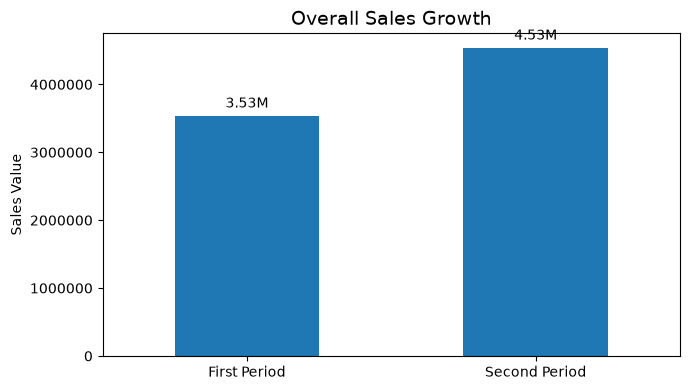

In [7159]:
plt.figure(figsize=(7, 4))

period_sales_display = period_sales.copy()
period_sales_display.index = ["First Period", "Second Period"]

ax = period_sales_display.plot(kind="bar", legend=False)

plt.title("Overall Sales Growth", fontsize=14)
plt.xlabel("")
plt.ylabel("Sales Value")
plt.xticks(rotation=0)

ax.ticklabel_format(style="plain", axis="y")

for container in ax.containers:
    labels = [f"{value/1_000_000:.2f}M" for value in period_sales_display.values]
    ax.bar_label(container, labels=labels, padding=4)

plt.tight_layout()
plt.show()

In [7160]:
segment_counts = (
    customer_clean["behavior_type"]
    .value_counts()
    .reindex([
        "Frequency + Basket Spend Increased",
        "Frequency Increased, Basket Spend Decreased",
        "Frequency Decreased, Basket Spend Increased",
        "Frequency + Basket Spend Decreased"
    ])
)

segment_counts

behavior_type
Frequency + Basket Spend Increased             813
Frequency Increased, Basket Spend Decreased    725
Frequency Decreased, Basket Spend Increased    477
Frequency + Basket Spend Decreased             394
Name: count, dtype: int64

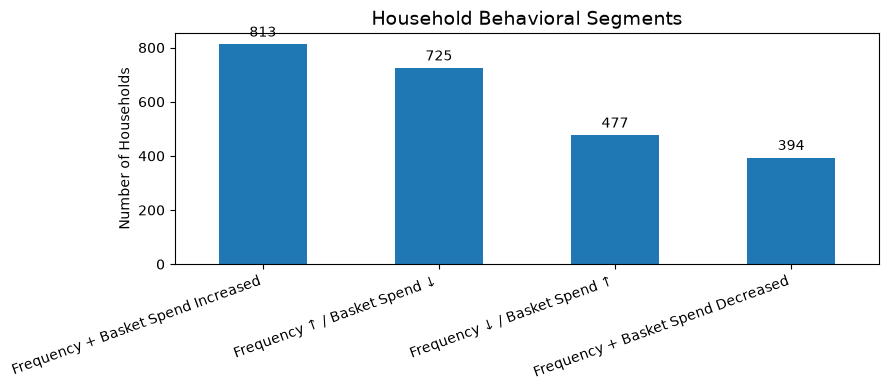

In [7161]:
plt.figure(figsize=(9, 4))

segment_counts_display = segment_counts.copy()

segment_counts_display.index = [
    "Frequency + Basket Spend Increased",
    "Frequency ↑ / Basket Spend ↓",
    "Frequency ↓ / Basket Spend ↑",
    "Frequency + Basket Spend Decreased"
]

ax = segment_counts_display.plot(
    kind="bar",
    legend=False
)

plt.title("Household Behavioral Segments", fontsize=14)
plt.xlabel("")
plt.ylabel("Number of Households")
plt.xticks(rotation=20, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [7162]:
critical_sales_change = customer_clean.loc[
    customer_clean["behavior_type"] == "Frequency + Basket Spend Decreased",
    "sales_change"
].sum()

critical_sales_change

np.float64(-284393.82999999996)

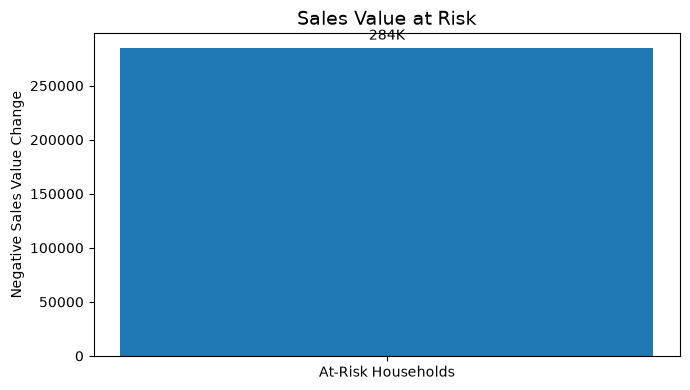

In [7163]:
plt.figure(figsize=(7, 4))

ax = plt.bar(
    ["At-Risk Households"],
    [abs(critical_sales_change)]
)

plt.title("Sales Value at Risk", fontsize=14)
plt.ylabel("Negative Sales Value Change")

plt.bar_label(
    ax,
    labels=[f"{abs(critical_sales_change)/1_000:.0f}K"],
    padding=4
)

plt.tight_layout()
plt.show()

In [7164]:
top_category_losses = (
    critical_category_sales[
        critical_category_sales["first_period"] >= 10000
    ]
    .sort_values("sales_loss", ascending=False)
    .head(7)
    [["sales_loss"]]
)

top_category_losses

period,sales_loss
DEPARTMENT,
GROCERY,150744.03
DRUG GM,38019.98
MEAT,22057.85
MEAT-PCKGD,17775.91
PRODUCE,16809.56
KIOSK-GAS,15614.98
DELI,8896.78


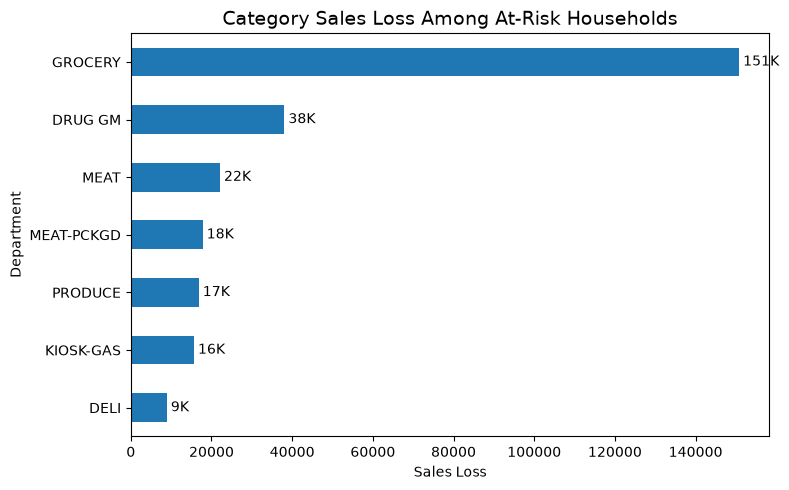

In [7165]:
plt.figure(figsize=(8, 5))

ax = top_category_losses["sales_loss"].sort_values().plot(
    kind="barh"
)

plt.title("Category Sales Loss Among At-Risk Households", fontsize=14)
plt.xlabel("Sales Loss")
plt.ylabel("Department")

for container in ax.containers:
    labels = [f"{value/1_000:.0f}K" for value in top_category_losses["sales_loss"].sort_values()]
    ax.bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()

# Executive Insights

## 1. Overall growth masks customer-level risk

Total sales increased by 28.4% between the first and second periods. However, growth was not evenly distributed across households.

## 2. A meaningful customer segment is reducing engagement

871 households reduced purchase frequency between the two periods.

Among them, 394 households experienced declines in both purchase frequency and basket spend.

## 3. The critical segment represents a material sales risk

The 394 households with declining frequency and basket spend generated approximately 284K in negative sales value change.

## 4. The decline is broad-based across core categories

Grocery represents the largest sales loss within the critical segment, followed by Drug GM, Meat, Meat-Pckgd, Produce and Kiosk-Gas.

## 5. Campaign exposure does not show a clear recovery pattern

236 of the 394 critical households appear in the campaign table. For Campaign 8, observed sales and basket frequency per active household remained below the earlier comparison period during and after the campaign.

This is an observational finding and does not establish campaign effectiveness or causality. Differences in period length and active-household composition should also be considered when interpreting the result.

# Opportunity

## Protect and rebuild value among at-risk households

The analysis identifies a clear opportunity to focus on the 394 households whose purchase frequency and basket spend both declined.

These households generated approximately 284K in negative sales value change and showed broad-based declines across core categories, with Grocery representing the largest loss.

The opportunity is therefore not simply to increase promotional activity, but to understand what is driving reduced engagement and identify targeted ways to rebuild shopping frequency and basket value.

### Opportunity areas

- Re-engage households showing declining purchase frequency.
- Identify category-level drivers of disengagement, particularly within Grocery.
- Distinguish between customers who need a frequency recovery strategy and those who need a basket-value recovery strategy.
- Evaluate whether campaign targeting and timing are aligned with the behavior of at-risk households.
- Test more targeted interventions rather than relying on broad campaign exposure alone.

# Strategic Options

Based on the identified customer risk, three strategic directions could be considered.

## Option 1 — Frequency Recovery

Focus on re-engaging households whose purchase frequency has declined.

**Objective:** Increase shopping frequency and rebuild habitual purchasing.

**Potential actions:**
- Trigger targeted re-engagement offers.
- Use category-specific reminders.
- Prioritize households with significant frequency decline.

**Trade-off:** May require more frequent customer contact and promotional investment without necessarily increasing basket value.

---

## Option 2 — Basket Value Recovery

Focus on households that continue to shop but are spending less per basket.

**Objective:** Increase value per shopping occasion.

**Potential actions:**
- Encourage cross-category purchases.
- Use personalized product or category recommendations.
- Develop basket-building offers.

**Trade-off:** May have limited impact on households whose primary problem is declining shopping frequency.

---

## Option 3 — Targeted Recovery Strategy

Combine frequency and basket-value recovery, while prioritizing customers and categories based on observed behavior.

**Objective:** Match the intervention to the customer's specific behavioral problem.

**Potential actions:**
- Segment at-risk households by frequency and basket-value behavior.
- Prioritize Grocery and other categories with material sales losses.
- Use campaign timing and customer behavior to determine intervention timing.
- Test targeted interventions before scaling.

**Trade-off:** More complex to execute and requires stronger customer-level targeting and measurement.

# Recommendation

## Prioritize a targeted customer recovery strategy

The analysis suggests that the most relevant strategic direction is to move from broad customer engagement toward more targeted recovery efforts.

The 394 households with declining frequency and basket spend represent a concentrated area of customer-value risk, with approximately 284K in negative sales value change.

Rather than applying the same intervention to all at-risk households, the business could differentiate its approach based on the underlying behavioral pattern:

- **Frequency decline:** focus on re-engagement and rebuilding shopping habits.
- **Basket-value decline:** focus on increasing value per shopping occasion.
- **Both frequency and basket-value decline:** prioritize targeted recovery interventions and closer measurement.

Grocery should receive particular attention because it represents the largest category-level sales loss within the critical segment.

### Measurement principle

Any recovery initiative should be tested against customer behavior before and after intervention, with purchase frequency and basket value tracked separately.

The campaign analysis in this project is observational and does not establish causal campaign impact. Future interventions should therefore be evaluated through controlled testing where possible.